# Experiment 2: Heterogenous Tissue
**Drug Modeled:** Gefitinib

**Condition Tested:** Diffusion through dense, heterogenous tumor tissue

**Research Question:** How does tissue structure influence drug delivery?

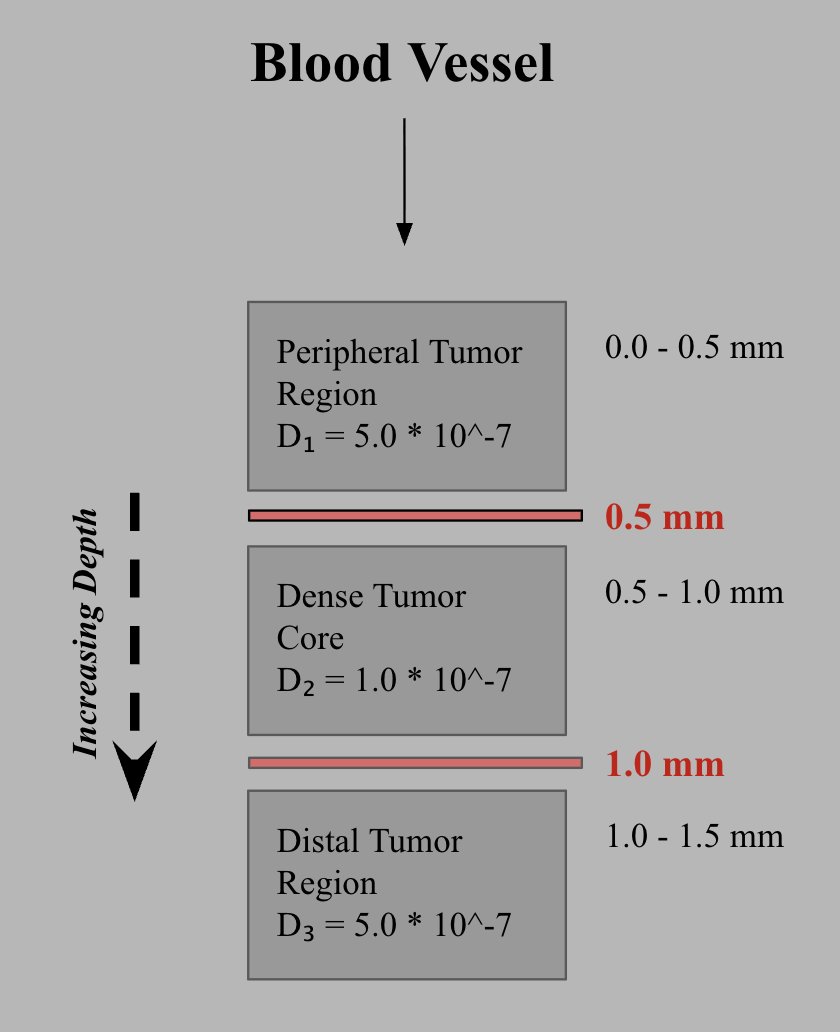

In [20]:
from IPython.display import Image

Image('figures/exp02_layered_tissue_schematic.png', width = 500)

## Figure 2A

**Figure 2A.** Schematic representation of the heterogeneous tissue model governing this experiment.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Effective diffusion coefficient for gefitinib in tumor tissue
D = 5e-7            # cm^2 /s

# Normalized source concentration
# Relative concentration used to study spatial gradients
C0 = 1.0            # arbitrary units

# Tissue depth range
# 0-2 mm into tumor tissue
x = np.linspace(0, 0.2, 1000)       # cm

# Single time point
# 1 hour after drug exposure
t = 3600            # seconds

In [22]:
import numpy as np

# Analytical Solution to Fick's Second Law

# Fundamental solution of the 1D diffusion equation

# Represents spatial redistribution of drug from an initial source

normalization = 1 / np.sqrt(4 * np.pi * D * t)

# Gefitinib concentration profile as a function of depth

C = C0 * normalization * np.exp(-(x**2) / (4 * D * t))

ny = 100

C_heatmap = np.tile(C, (ny, 1))

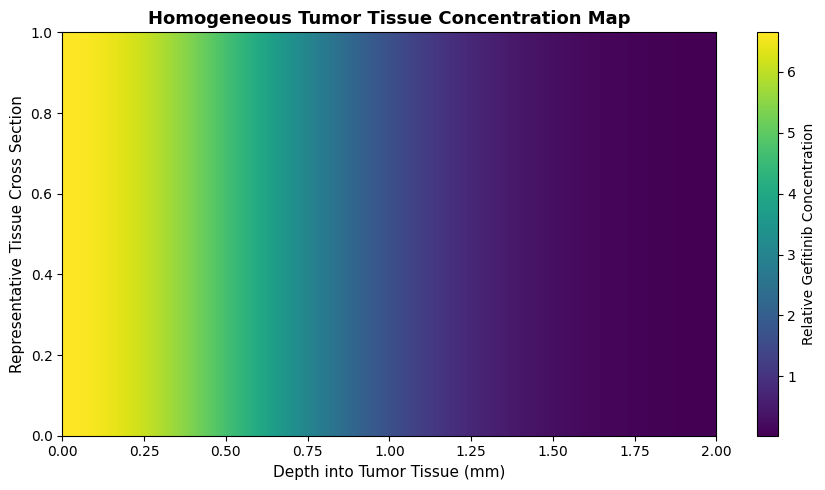

In [23]:
import os
os.makedirs('figures', exist_ok=True)

# Plot

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(
    C_heatmap,
    aspect='auto',
    cmap='viridis',
    origin='lower',
    extent=[0, x.max() * 10, 0, 1]
)

# Labels and formatting
ax.set_title(
    'Homogeneous Tumor Tissue Concentration Map',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel(
    'Depth into Tumor Tissue (mm)',
    fontsize=11
)

ax.set_ylabel(
    'Representative Tissue Cross Section',
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Relative Gefitinib Concentration')

plt.tight_layout()

plt.savefig(
    'figures/exp02_homogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Figure 2B

**Figure 2B.** Simulated gefitinib concentration distribution in homogeneous tumor tissue. Drug concentration decreases smoothly with increasing depth, producing a continuous concentration gradient in the absence of structural heterogeneity.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

In [25]:
C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

0.0
0.0089990939045322
0.006782044999999999
0.23125347613948122


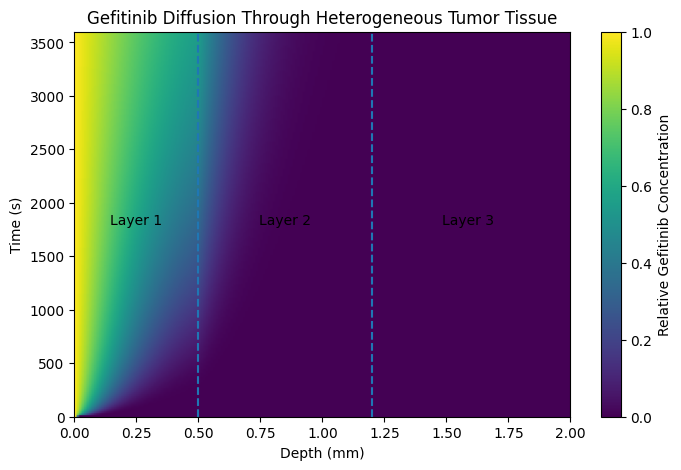

In [34]:
C_heatmap = np.array(saved_profiles)

print(C_heatmap[0, 100])
print(C_heatmap[-1, 100])

print(np.mean(C_heatmap[0]))
print(np.mean(C_heatmap[-1]))

plt.figure(figsize=(8, 5))

plt.imshow(

    C_heatmap,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

plt.colorbar(label='Relative Gefitinib Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp02_heterogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

## Figure 2C

**Figure 2C.** Spatial–temporal heatmap of gefitinib diffusion through heterogeneous tumor tissue. Vertical dashed lines indicate transitions between tissue layers with different diffusion coefficients. The low-diffusivity middle layer acts as a transport barrier, slowing drug penetration and producing reduced concentrations at greater depths.